In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [2]:
data=pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv")

<Axes: >

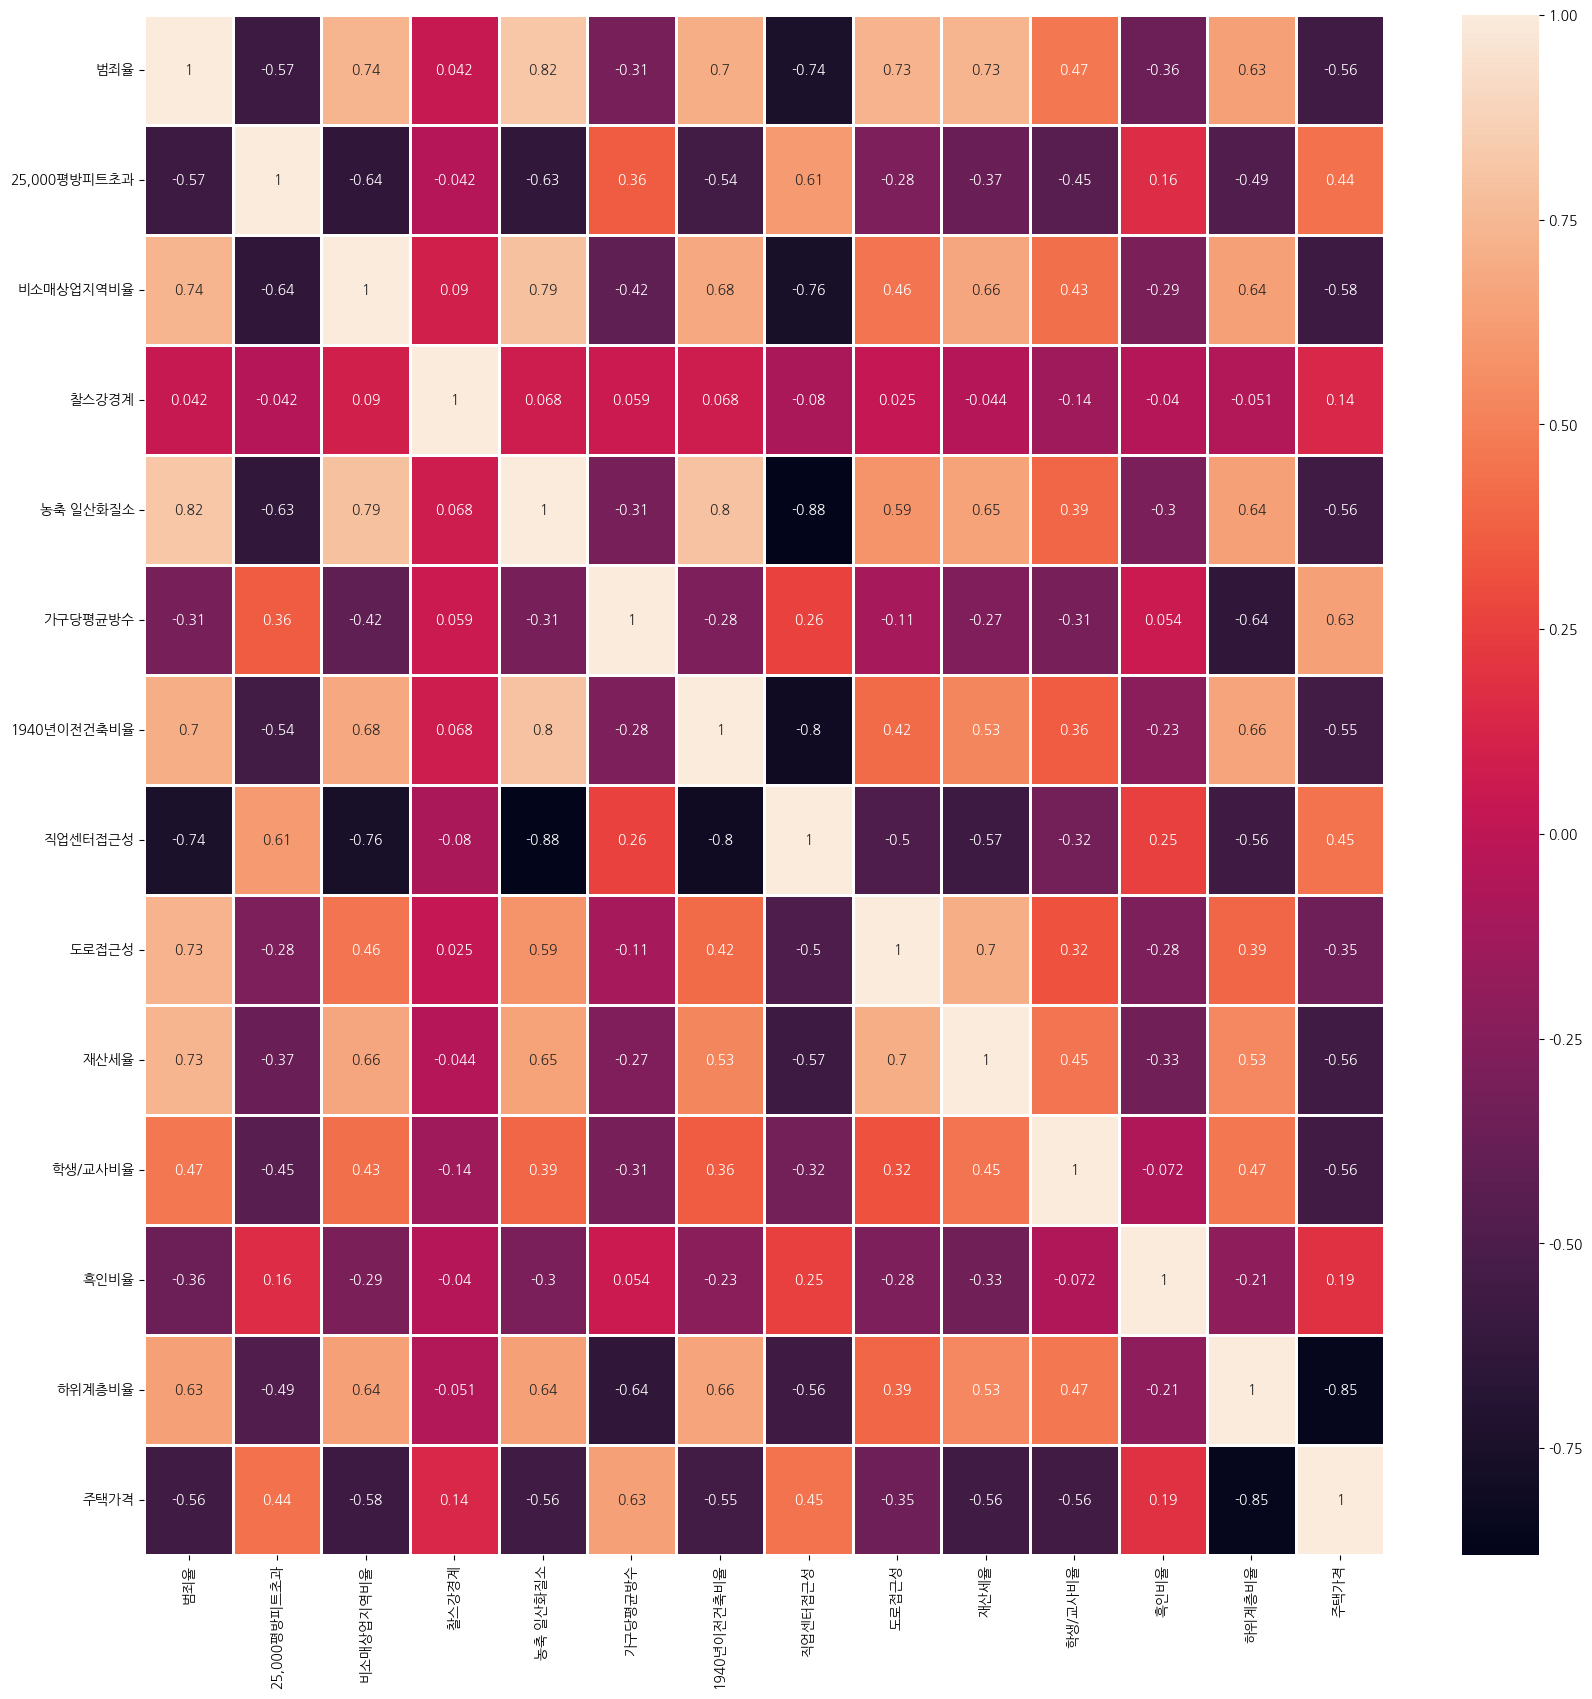

In [4]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(method='spearman'), annot=True, linewidth=1)

In [5]:
X=data.drop('주택가격', axis=1)
y=data['주택가격']

In [6]:
X

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [7]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: 주택가격, Length: 506, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train2 = X_train.copy()
X_test2=X_test.copy()

스케일 맞추기

In [11]:
from sklearn.preprocessing import RobustScaler

In [12]:
rs=RobustScaler()
rs.fit(X_train)
rs_X_train= rs.transform(X_train)
rs_X_test= rs.transform(X_test)
rs_X_train=pd.DataFrame(rs_X_train, columns=X_train.columns, index=X_train.index)
rs_X_test=pd.DataFrame(rs_X_test, columns=X_test.columns, index=X_test.index)

In [13]:
rs_X_train

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
5,-0.070845,0.0,-0.579029,0.0,-0.441989,0.255601,-0.393045,0.888157,-0.10,-0.279070,0.028169,0.129964,-0.610414
116,-0.039048,0.0,0.024672,0.0,0.049724,-0.065005,-0.102213,-0.113375,0.05,0.263566,-0.225352,0.087674,0.119092
45,-0.026596,0.0,-0.214341,0.0,-0.497238,-0.688545,-0.917808,0.599068,-0.10,-0.250646,-0.197183,0.273337,-0.076368
16,0.249243,0.0,-0.119507,0.0,0.000000,-0.369202,-1.012645,0.418185,-0.05,-0.059432,0.676056,-0.244972,-0.464085
468,4.788193,0.0,0.648419,0.0,0.232044,-0.380562,-0.133825,-0.059784,0.95,0.868217,0.450704,-1.178958,0.769559
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.026665,0.0,-0.087124,0.0,-0.099448,-0.494162,0.306639,-0.269402,0.00,0.139535,0.647887,0.209902,0.826168
270,0.013331,1.0,-0.210486,0.0,-0.408840,-0.468918,-0.742887,0.397265,-0.10,-0.276486,0.000000,-0.152140,0.221629
348,-0.075484,4.0,-0.592136,0.0,-0.569061,0.514358,-1.004215,1.574001,-0.05,-0.129199,-0.450704,-0.034038,-0.527103
435,3.408139,0.0,0.648419,0.0,1.116022,0.506784,0.363541,-0.295341,0.95,0.868217,0.450704,-14.530686,1.318558


In [14]:
rs_X_test

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
173,-0.051488,0.0,-0.434850,0.0,-0.154696,0.237930,0.142255,-0.138563,0.00,-0.087855,-0.563380,0.201135,-0.201335
274,-0.062534,2.0,-0.252891,1.0,-0.502762,0.669612,-0.936776,0.291644,-0.05,-0.196382,-0.281690,0.273337,-0.789853
491,-0.047125,0.0,1.391673,0.0,0.392265,-0.308615,0.452055,-0.372468,-0.05,0.984496,0.422535,-0.076844,0.763151
72,-0.051532,0.0,0.086353,0.0,-0.690608,-0.205112,-1.465753,0.655245,-0.05,-0.064599,0.169014,-0.035585,-0.577303
452,1.510817,0.0,0.648419,0.0,0.966851,0.087725,0.304531,-0.222152,0.95,0.868217,0.450704,-0.335740,0.677704
...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,2.959232,0.0,0.648419,0.0,1.116022,0.225308,0.418335,-0.313255,0.95,0.868217,0.450704,-0.290872,0.918024
23,0.228770,0.0,-0.119507,0.0,0.000000,-0.523193,0.477345,0.296934,-0.05,-0.059432,0.676056,0.151625,0.956475
225,0.084523,0.0,-0.269082,0.0,-0.187845,3.152414,0.119073,-0.063992,0.15,-0.059432,-0.338028,-0.495101,-0.672363
433,1.664254,0.0,0.648419,0.0,0.966851,0.263175,0.222339,-0.237902,0.95,0.868217,0.450704,-15.028881,0.565554


# 선형회귀분석

In [15]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# 상수항 추가
rs_X_train_const=sm.add_constant(rs_X_train)
rs_X_test_const=sm.add_constant(rs_X_test)

In [17]:
rs_X_train_const

,const,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
5,1.0,-0.070845,0.0,-0.579029,0.0,-0.441989,0.255601,-0.393045,0.888157,-0.10,-0.279070,0.028169,0.129964,-0.610414
116,1.0,-0.039048,0.0,0.024672,0.0,0.049724,-0.065005,-0.102213,-0.113375,0.05,0.263566,-0.225352,0.087674,0.119092
45,1.0,-0.026596,0.0,-0.214341,0.0,-0.497238,-0.688545,-0.917808,0.599068,-0.10,-0.250646,-0.197183,0.273337,-0.076368
16,1.0,0.249243,0.0,-0.119507,0.0,0.000000,-0.369202,-1.012645,0.418185,-0.05,-0.059432,0.676056,-0.244972,-0.464085
468,1.0,4.788193,0.0,0.648419,0.0,0.232044,-0.380562,-0.133825,-0.059784,0.95,0.868217,0.450704,-1.178958,0.769559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,1.0,-0.026665,0.0,-0.087124,0.0,-0.099448,-0.494162,0.306639,-0.269402,0.00,0.139535,0.647887,0.209902,0.826168
270,1.0,0.013331,1.0,-0.210486,0.0,-0.408840,-0.468918,-0.742887,0.397265,-0.10,-0.276486,0.000000,-0.152140,0.221629
348,1.0,-0.075484,4.0,-0.592136,0.0,-0.569061,0.514358,-1.004215,1.574001,-0.05,-0.129199,-0.450704,-0.034038,-0.527103
435,1.0,3.408139,0.0,0.648419,0.0,1.116022,0.506784,0.363541,-0.295341,0.95,0.868217,0.450704,-14.530686,1.318558


In [18]:
rs_X_test_const

,const,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
173,1.0,-0.051488,0.0,-0.434850,0.0,-0.154696,0.237930,0.142255,-0.138563,0.00,-0.087855,-0.563380,0.201135,-0.201335
274,1.0,-0.062534,2.0,-0.252891,1.0,-0.502762,0.669612,-0.936776,0.291644,-0.05,-0.196382,-0.281690,0.273337,-0.789853
491,1.0,-0.047125,0.0,1.391673,0.0,0.392265,-0.308615,0.452055,-0.372468,-0.05,0.984496,0.422535,-0.076844,0.763151
72,1.0,-0.051532,0.0,0.086353,0.0,-0.690608,-0.205112,-1.465753,0.655245,-0.05,-0.064599,0.169014,-0.035585,-0.577303
452,1.0,1.510817,0.0,0.648419,0.0,0.966851,0.087725,0.304531,-0.222152,0.95,0.868217,0.450704,-0.335740,0.677704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,1.0,2.959232,0.0,0.648419,0.0,1.116022,0.225308,0.418335,-0.313255,0.95,0.868217,0.450704,-0.290872,0.918024
23,1.0,0.228770,0.0,-0.119507,0.0,0.000000,-0.523193,0.477345,0.296934,-0.05,-0.059432,0.676056,0.151625,0.956475
225,1.0,0.084523,0.0,-0.269082,0.0,-0.187845,3.152414,0.119073,-0.063992,0.15,-0.059432,-0.338028,-0.495101,-0.672363
433,1.0,1.664254,0.0,0.648419,0.0,0.966851,0.263175,0.222339,-0.237902,0.95,0.868217,0.450704,-15.028881,0.565554


In [19]:
ols=sm.OLS(y_train, rs_X_train_const).fit()
pred=ols.predict(rs_X_test_const)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

MAE:  3.1627098714574053
MSE:  21.51744423117721
RMSE:  4.6386899261728205
R2:  0.7112260057484932


In [20]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Thu, 08 May 2025   Prob (F-statistic):           4.96e-92
Time:                        14:33:26   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.9494      0.408     58.755   

In [21]:
result=pd.DataFrame(dict(y_test=y_test, pred=pred))
result

,y_test,pred
173,23.6,28.648960
274,32.4,36.495014
491,13.6,15.411193
72,22.8,25.403213
452,16.1,18.855280
...,...,...
441,17.1,17.403672
23,14.5,13.385941
225,50.0,39.983425
433,14.3,16.682863


In [23]:
result['잔차']=result['y_test']-result['pred']
result['잔차제곱']=result['잔차']**2
result['MSE']=result['잔차제곱'].mean()
result['RMSE']=result['MSE'].apply(np.sqrt)
result

,y_test,pred,잔차,잔차제곱,MSE,RMSE
173,23.6,28.648960,-5.048960,25.491998,21.517444,4.63869
274,32.4,36.495014,-4.095014,16.769138,21.517444,4.63869
491,13.6,15.411193,-1.811193,3.280421,21.517444,4.63869
72,22.8,25.403213,-2.603213,6.776718,21.517444,4.63869
452,16.1,18.855280,-2.755280,7.591567,21.517444,4.63869
...,...,...,...,...,...,...
441,17.1,17.403672,-0.303672,0.092216,21.517444,4.63869
23,14.5,13.385941,1.114059,1.241127,21.517444,4.63869
225,50.0,39.983425,10.016575,100.331779,21.517444,4.63869
433,14.3,16.682863,-2.382863,5.678036,21.517444,4.63869


# 최적회귀 구하기(단계적 변수 선택법)
* 1) 전진선택법
* 2) 후진제거법


In [24]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()

* 전진선택법으로 분석

In [32]:
sfs_fw =  SequentialFeatureSelector(estimator=model, direction='forward', scoring='r2', cv=5, n_jobs=4)
sfs_fw.fit(rs_X_train_const, y_train)
print(sfs_fw.get_support()) # 전진선택법으로 선택된 컬럼들 선택
selected_cols = rs_X_train_const.columns[sfs_fw.get_support()]
print("전진선택법으로 선택된 컬럼: ", list(selected_cols))

[False  True False False  True  True  True False  True False False  True
 False  True]
전진선택법으로 선택된 컬럼:  ['범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']


In [33]:
print("원래 컬럼수: ", len(rs_X_train_const.columns))
print("selected_cols: ", len(selected_cols))

원래 컬럼수:  14
selected_cols:  7


In [34]:
selected_cols

Index(['범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율'], dtype='object')

In [35]:
fw_X_train=rs_X_train_const[['const','범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']]
fw_X_test=rs_X_train_const[['const','범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']]

In [36]:
ols2=sm.OLS(y_train, fw_X_train).fit()
pred=ols2.predict(fw_X_test)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

ValueError: Found input variables with inconsistent numbers of samples: [152, 354]

후진제거법

In [37]:
sfs_bw =  SequentialFeatureSelector(estimator=model, direction='backward', scoring='r2', cv=5, n_jobs=4)
sfs_bw.fit(rs_X_train_const, y_train)
print(sfs_bw.get_support()) # 전진선택법으로 선택된 컬럼들 선택
selected_cols = rs_X_train_const.columns[sfs_bw.get_support()]
print("후진선택법으로 선택된 컬럼: ", list(selected_cols))
print("원래 컬럼수: ", len(rs_X_train_const.columns))
print("selected_cols: ", len(selected_cols))

[False  True False False False  True  True False  True  True False  True
 False  True]
후진선택법으로 선택된 컬럼:  ['범죄율', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '도로접근성', '학생/교사비율', '하위계층비율']
원래 컬럼수:  14
selected_cols:  7


In [38]:
bw_X_train=rs_X_train_const[['const','범죄율', '도로접근성','농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']]
bw_X_test=rs_X_train_const[['const','범죄율', '도로접근성', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']]

In [39]:
ols3=sm.OLS(y_train, bw_X_train).fit()
pred=ols3.predict(bw_X_test)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

ValueError: Found input variables with inconsistent numbers of samples: [152, 354]

In [ ]:
print(ols3.summary())

In [41]:
arg=[1,2,3,4]
print(*arg)
print(arg)

1 2 3 4
[1, 2, 3, 4]


In [ ]:
def my_sum(*args):
    hap=0
    for i in args:
        hap=hap+i
    return hap

In [ ]:
my_sum(*list(range(1, 1001)))

In [ ]:
def muls(a, *args):
    print(a, args)
    result=[]
    for num in args:
        result.append(a*num)
    return result

In [ ]:
l2=[1,2,3,4,5]

In [ ]:
def muls(a, *args):
    print(a, args)
    result=[]
    for num in args:
        result.append(a*num)

In [ ]:
def muls(*args, a):
    print(a, args)
    result=[]
    for n

In [ ]:
print(1,2,3, sep="$")

In [42]:
personal_info(**{'address': '서울시 강남구', 'name':'홍길동','age':30})

NameError: name 'personal_info' is not defined

In [43]:
def personal_info(name, age, address):
    print("이름: ", name)
    print("나이: ", age)
    print("주소: ", address)

In [47]:
info={'name':'구현선', 'age':29, 'address':'사당동'}

In [48]:
personal_info(**info)

이름:  구현선
나이:  29
주소:  사당동


In [51]:
def personal_info2(**kwargs):
    print(kwargs)

In [52]:
personal_info2(address='서울시', name='홍길동')

{'address': '서울시', 'name': '홍길동'}


In [ ]:
def personal_info3(num, **kwargs):
    print(kwargs)
    
    

In [ ]:
def custom_print(*args, **kwargs):
    print(*args, **kwargs)

In [ ]:
custom_print(1,2,3, sep="")

In [ ]:
def custom_print(**kwargs, *args):
    print(*args, **kwargs)
    print(*args, **kwargs)

In [ ]:
def personal_info6(idx, address='비공개', *args, **kwargs):
    print(f"idx: {idx}")
    print(f"address:{address}")
    print(f"*args:{args}")
    

In [ ]:
personal_info6(1, "서울", 30, 40, )